In [1]:
import numpy as np
import matplotlib.pyplot as plt


def loss_function(x, y):
    """Purpose-built two-parameter loss surface used in Exercise 3."""
    valley = y - 0.2 * x
    return (
        0.05 * (x - 1)**2 * (x - 4)**2
        - 0.2 * x
        + 0.4 * valley**2
        + 1.0
    )


def loss_gradient(x, y):
    """Return the exact gradient [dJ/dx, dJ/dy]."""
    valley = y - 0.2 * x
    return np.array([
        0.1 * (x - 1) * (x - 4) * (2 * x - 5)
        - 0.2
        - 0.16 * valley,
        0.8 * valley,
    ], dtype=float)


def _scalar_loss(loss_function, point):
    """Evaluate a two-parameter loss function and return one finite float."""
    value = np.asarray(loss_function(float(point[0]), float(point[1])), dtype=float)
    if value.size != 1:
        raise ValueError("The loss function must return one value for one point.")
    scalar = float(value.reshape(-1)[0])
    if not np.isfinite(scalar):
        raise ValueError("The loss function returned a non-finite value.")
    return scalar


def _exact_gradient(gradient_function, point):
    """Evaluate and validate the exact two-parameter gradient."""
    point = np.asarray(point, dtype=float)
    if point.shape != (2,):
        raise ValueError("point must contain exactly two values: [x, y].")
    gradient = np.asarray(
        gradient_function(float(point[0]), float(point[1])),
        dtype=float,
    )
    if gradient.shape != (2,) or not np.all(np.isfinite(gradient)):
        raise ValueError("The gradient function must return two finite values.")
    return gradient


def run_gradient_descent(
    loss_function,
    gradient_function,
    start_point,
    learning_rate,
    iterations,
    gradient_tolerance=1e-4,
    divergence_limit=1e6,
):
    """Run gradient descent using the exact gradient."""
    point = np.asarray(start_point, dtype=float)
    if point.shape != (2,) or not np.all(np.isfinite(point)):
        raise ValueError("START_POINT must contain two finite values: [x, y].")
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("LEARNING_RATE must be a positive finite number.")
    if not isinstance(iterations, (int, np.integer)) or iterations <= 0:
        raise ValueError("ITERATIONS must be a positive integer.")

    path = [point.copy()]
    losses = [_scalar_loss(loss_function, point)]
    gradients = []
    gradient_magnitudes = []
    step_lengths = []
    status = "iteration limit reached"

    for _ in range(iterations):
        gradient = _exact_gradient(gradient_function, point)
        gradient_magnitude = float(np.linalg.norm(gradient))
        gradients.append(gradient.copy())
        gradient_magnitudes.append(gradient_magnitude)

        if gradient_magnitude < gradient_tolerance:
            status = "converged: gradient is near zero"
            break

        new_point = point - learning_rate * gradient
        if not np.all(np.isfinite(new_point)) or np.linalg.norm(new_point) > divergence_limit:
            status = "stopped: parameter values diverged"
            break

        try:
            new_loss = _scalar_loss(loss_function, new_point)
        except ValueError:
            status = "stopped: loss became non-finite"
            break

        step_lengths.append(float(np.linalg.norm(new_point - point)))
        point = new_point
        path.append(point.copy())
        losses.append(new_loss)

    path = np.asarray(path)
    losses = np.asarray(losses)
    final_gradient = _exact_gradient(gradient_function, path[-1])
    final_gradient_magnitude = float(np.linalg.norm(final_gradient))

    if status == "iteration limit reached" and final_gradient_magnitude < 10 * gradient_tolerance:
        status = "nearly converged: surface is almost flat"

    lowest_index = int(np.argmin(losses))
    loss_increases = int(np.sum(np.diff(losses) > 1e-10))

    return {
        "path": path,
        "losses": losses,
        "gradients": np.asarray(gradients),
        "gradient_magnitudes": np.asarray(gradient_magnitudes),
        "step_lengths": np.asarray(step_lengths),
        "lowest_index": lowest_index,
        "loss_increases": loss_increases,
        "final_gradient": final_gradient,
        "final_gradient_magnitude": final_gradient_magnitude,
        "status": status,
        "learning_rate": float(learning_rate),
        "requested_iterations": int(iterations),
    }


def evaluate_surface(
    loss_function,
    path,
    x_limits=(-0.5, 5.0),
    y_limits=(-1.3, 1.5),
    resolution=180,
):
    """Evaluate the loss on a grid and locate the lowest displayed point."""
    path = np.asarray(path)
    x_low = min(x_limits[0], float(path[:, 0].min()) - 0.2)
    x_high = max(x_limits[1], float(path[:, 0].max()) + 0.2)
    y_low = min(y_limits[0], float(path[:, 1].min()) - 0.2)
    y_high = max(y_limits[1], float(path[:, 1].max()) + 0.2)

    x_values = np.linspace(x_low, x_high, resolution)
    y_values = np.linspace(y_low, y_high, resolution)
    X, Y = np.meshgrid(x_values, y_values)

    try:
        Z = np.asarray(loss_function(X, Y), dtype=float)
        if Z.shape != X.shape:
            raise ValueError
    except Exception:
        Z = np.vectorize(lambda x, y: _scalar_loss(loss_function, [x, y]))(X, Y)

    finite_mask = np.isfinite(Z)
    if not finite_mask.any():
        raise ValueError("The loss function is non-finite over the displayed region.")
    finite_indices = np.where(finite_mask)
    relative_index = int(np.argmin(Z[finite_mask]))
    row = int(finite_indices[0][relative_index])
    column = int(finite_indices[1][relative_index])

    return {
        "X": X,
        "Y": Y,
        "Z": Z,
        "grid_minimum_point": np.array([X[row, column], Y[row, column]]),
        "grid_minimum_loss": float(Z[row, column]),
    }


def print_summary(result, surface):
    """Print the values needed to interpret the optimisation run."""
    path = result["path"]
    losses = result["losses"]
    lowest_index = result["lowest_index"]

    print("GRADIENT DESCENT SUMMARY")
    print(f"Learning rate:                 {result['learning_rate']:.4g}")
    print(f"Updates completed:             {len(path) - 1} / {result['requested_iterations']}")
    print(f"Starting point:                ({path[0, 0]:.4f}, {path[0, 1]:.4f})")
    print(f"Starting loss:                 {losses[0]:.6f}")
    if len(result["gradients"]) > 0:
        first_gradient = result["gradients"][0]
        print(f"Exact starting gradient [dJ/dx,dJ/dy]: [{first_gradient[0]:.4f}, {first_gradient[1]:.4f}]")
    if len(path) > 1:
        print(f"First updated point:           ({path[1, 0]:.4f}, {path[1, 1]:.4f})")
        print(f"First step length:             {result['step_lengths'][0]:.6f}")
    print(f"Final point:                   ({path[-1, 0]:.4f}, {path[-1, 1]:.4f})")
    print(f"Final loss:                    {losses[-1]:.6f}")
    print(f"Total loss reduction:          {losses[0] - losses[-1]:.6f}")
    print(f"Lowest visited point:          ({path[lowest_index, 0]:.4f}, {path[lowest_index, 1]:.4f})")
    print(f"Lowest visited loss:           {losses[lowest_index]:.6f}")
    print(f"Final gradient magnitude:      {result['final_gradient_magnitude']:.6e}")
    print(f"Uphill updates:                {result['loss_increases']}")
    print(f"Status:                        {result['status']}")
    print()
    grid_point = surface["grid_minimum_point"]
    print("DISPLAYED SURFACE REFERENCE (grid estimate)")
    print(f"Lowest displayed point:        ({grid_point[0]:.4f}, {grid_point[1]:.4f})")
    print(f"Lowest displayed loss:         {surface['grid_minimum_loss']:.6f}")
    print(f"Final-to-displayed loss gap:   {losses[-1] - surface['grid_minimum_loss']:.6f}")


def _padded_finite_range(*arrays, padding=0.06):
    """Return finite data limits with proportional padding."""
    finite_values = []
    for array in arrays:
        values = np.asarray(array, dtype=float).reshape(-1)
        finite_values.append(values[np.isfinite(values)])

    finite_values = np.concatenate(finite_values)
    if finite_values.size == 0:
        raise ValueError("The plot contains no finite values.")

    lower = float(finite_values.min())
    upper = float(finite_values.max())
    span = upper - lower
    if span == 0:
        span = max(abs(lower), 1.0)
    margin = padding * span
    return lower - margin, upper + margin


def plot_simulation(result, surface):
    """Plot the 3D loss surface, parameter path and loss history."""
    path = result["path"]
    losses = result["losses"]
    grid_point = surface["grid_minimum_point"]

    finite_surface_loss = surface["Z"][np.isfinite(surface["Z"])]
    x_range = _padded_finite_range(surface["X"], path[:, 0])
    y_range = _padded_finite_range(surface["Y"], path[:, 1])
    z_range = _padded_finite_range(finite_surface_loss, losses)
    box_spans = np.array([
        x_range[1] - x_range[0],
        y_range[1] - y_range[0],
        z_range[1] - z_range[0],
    ])
    box_aspect = np.clip(box_spans / box_spans.max(), 0.35, 1.0)

    fig = plt.figure(figsize=(13, 5.5))
    ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
    ax_surface.plot_surface(
        surface["X"], surface["Y"], surface["Z"],
        cmap="viridis", alpha=0.68, linewidth=0, antialiased=True,
    )
    ax_surface.plot(
        path[:, 0], path[:, 1], losses,
        color="crimson", marker="o", markersize=3, linewidth=2.4,
        label="Gradient-descent path",
    )
    ax_surface.scatter(
        path[0, 0], path[0, 1], losses[0],
        color="black", s=65, label="Start",
    )
    ax_surface.scatter(
        path[-1, 0], path[-1, 1], losses[-1],
        color="orange", edgecolor="black", s=70, label="Final point",
    )
    ax_surface.scatter(
        grid_point[0], grid_point[1], surface["grid_minimum_loss"],
        color="cyan", edgecolor="black", s=65,
        label="Lowest displayed grid point",
    )
    ax_surface.set_xlabel("Parameter x")
    ax_surface.set_ylabel("Parameter y")
    ax_surface.set_zlabel("Loss J(x, y)")
    ax_surface.set_title("Loss surface and optimisation path")
    ax_surface.view_init(elev=28, azim=65)
    ax_surface.set_xlim(*x_range)
    ax_surface.set_ylim(*y_range)
    ax_surface.set_zlim(*z_range)
    ax_surface.set_box_aspect(tuple(box_aspect), zoom=0.78)
    ax_surface.legend(loc="upper left", fontsize=8)

    ax_loss = fig.add_subplot(1, 2, 2)
    ax_loss.plot(np.arange(len(losses)), losses, color="crimson", marker="o", markersize=3)
    ax_loss.axhline(surface["grid_minimum_loss"], color="teal", linestyle="--", label="Lowest displayed grid loss")
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("Loss J(x, y)")
    ax_loss.set_title("Loss during gradient descent")
    ax_loss.grid(alpha=0.3)
    ax_loss.set_ylim(*_padded_finite_range(losses, surface["grid_minimum_loss"]))
    ax_loss.margins(x=0.03)
    ax_loss.legend()

    plt.tight_layout()
    plt.show()


def run_simulator(loss_function, gradient_function, learning_rate, iterations, start_point):
    """Run the complete simulation, print its summary and show both plots."""
    result = run_gradient_descent(
        loss_function=loss_function,
        gradient_function=gradient_function,
        start_point=start_point,
        learning_rate=learning_rate,
        iterations=iterations,
    )
    surface = evaluate_surface(loss_function, result["path"])
    print_summary(result, surface)
    plot_simulation(result, surface)
    return result


def plot_interactive_3d(loss_function, result):
    """Show a movable 3D surface with automatic framing."""
    try:
        import plotly.graph_objects as go
    except ImportError:
        import subprocess
        import sys

        subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
        import plotly.graph_objects as go

    interactive_surface = evaluate_surface(loss_function, result["path"])
    path = result["path"]
    losses = result["losses"]
    grid_point = interactive_surface["grid_minimum_point"]

    finite_surface_loss = interactive_surface["Z"][
        np.isfinite(interactive_surface["Z"])
    ]
    x_range = _padded_finite_range(interactive_surface["X"], path[:, 0])
    y_range = _padded_finite_range(interactive_surface["Y"], path[:, 1])
    z_range = _padded_finite_range(finite_surface_loss, losses)
    plot_spans = np.array([
        x_range[1] - x_range[0],
        y_range[1] - y_range[0],
        z_range[1] - z_range[0],
    ])
    plot_aspect = np.clip(plot_spans / plot_spans.max(), 0.35, 1.0)

    elevation = np.deg2rad(28)
    azimuth = np.deg2rad(65)
    camera_distance = 2.2
    camera = {
        "eye": {
            "x": camera_distance * np.cos(elevation) * np.cos(azimuth),
            "y": camera_distance * np.cos(elevation) * np.sin(azimuth),
            "z": camera_distance * np.sin(elevation),
        }
    }

    figure_3d = go.Figure()
    figure_3d.add_trace(
        go.Surface(
            x=interactive_surface["X"],
            y=interactive_surface["Y"],
            z=interactive_surface["Z"],
            colorscale="Viridis",
            opacity=0.72,
            showscale=False,
            name="Loss surface",
            hovertemplate="x=%{x:.3f}<br>y=%{y:.3f}<br>loss=%{z:.4f}<extra></extra>",
        )
    )
    figure_3d.add_trace(
        go.Scatter3d(
            x=path[:, 0],
            y=path[:, 1],
            z=losses,
            mode="lines+markers",
            line={"color": "crimson", "width": 6},
            marker={"color": "crimson", "size": 3},
            name="Gradient-descent path",
            hovertemplate="x=%{x:.4f}<br>y=%{y:.4f}<br>loss=%{z:.6f}<extra></extra>",
        )
    )
    figure_3d.add_trace(
        go.Scatter3d(
            x=[path[0, 0], path[-1, 0], grid_point[0]],
            y=[path[0, 1], path[-1, 1], grid_point[1]],
            z=[losses[0], losses[-1], interactive_surface["grid_minimum_loss"]],
            mode="markers",
            marker={
                "size": [8, 8, 8],
                "color": ["black", "orange", "cyan"],
                "line": {"color": "black", "width": 2},
            },
            text=["Start", "Final point", "Lowest displayed grid point"],
            name="Reference points",
            hovertemplate="%{text}<br>x=%{x:.4f}<br>y=%{y:.4f}<br>loss=%{z:.6f}<extra></extra>",
        )
    )
    figure_3d.update_layout(
        title="Interactive loss surface and optimisation path",
        height=700,
        scene={
            "xaxis": {"title": "Parameter x", "range": list(x_range)},
            "yaxis": {"title": "Parameter y", "range": list(y_range)},
            "zaxis": {"title": "Loss J(x, y)", "range": list(z_range)},
            "camera": camera,
            "dragmode": "orbit",
            "aspectmode": "manual",
            "aspectratio": {
                "x": float(plot_aspect[0]),
                "y": float(plot_aspect[1]),
                "z": float(plot_aspect[2]),
            },
        },
        margin={"l": 0, "r": 0, "b": 0, "t": 45},
        legend={"x": 0.01, "y": 0.99},
    )
    figure_3d.show(config={"scrollZoom": True, "displaylogo": False})


## Loss surface

$$J(x,y)=0.05(x-1)^2(x-4)^2-0.2x+0.4(y-0.2x)^2+1$$

- $0.05(x-1)^2(x-4)^2$ creates two broad basins near $x=1$ and $x=4$.
- $-0.2x$ tilts the surface so that the basin on the right is deeper.
- $0.4(y-0.2x)^2$ creates a sloping valley and increases the loss away from its centre line, $y=0.2x$.
- $+1$ shifts the surface upwards without changing its gradient or optimisation path.
- Lower values of $J$ represent lower loss.

The exact gradient is

$$\frac{\partial J}{\partial x}=0.1(x-1)(x-4)(2x-5)-0.2-0.16(y-0.2x)$$

$$\frac{\partial J}{\partial y}=0.8(y-0.2x)$$

Gradient descent updates both parameters using

$$x_{k+1}=x_k-\alpha\frac{\partial J}{\partial x}, \qquad
y_{k+1}=y_k-\alpha\frac{\partial J}{\partial y}$$

where $\alpha$ is the learning rate.


## Exercise 3 - Adjust controls here

GRADIENT DESCENT SUMMARY
Learning rate:                 0.5
Updates completed:             34 / 80
Starting point:                (0.0000, 0.0000)
Starting loss:                 1.800000
Exact starting gradient [dJ/dx,dJ/dy]: [-2.2000, 0.0000]
First updated point:           (1.1000, 0.0000)
First step length:             1.100000
Final point:                   (1.3136, 0.2627)
Final loss:                    0.772767
Total loss reduction:          1.027233
Lowest visited point:          (1.3136, 0.2627)
Lowest visited loss:           0.772767
Final gradient magnitude:      8.969070e-05
Uphill updates:                0
Status:                        converged: gradient is near zero

DISPLAYED SURFACE REFERENCE (grid estimate)
Lowest displayed point:        (4.2011, 0.8430)
Lowest displayed loss:         0.180504
Final-to-displayed loss gap:   0.592263


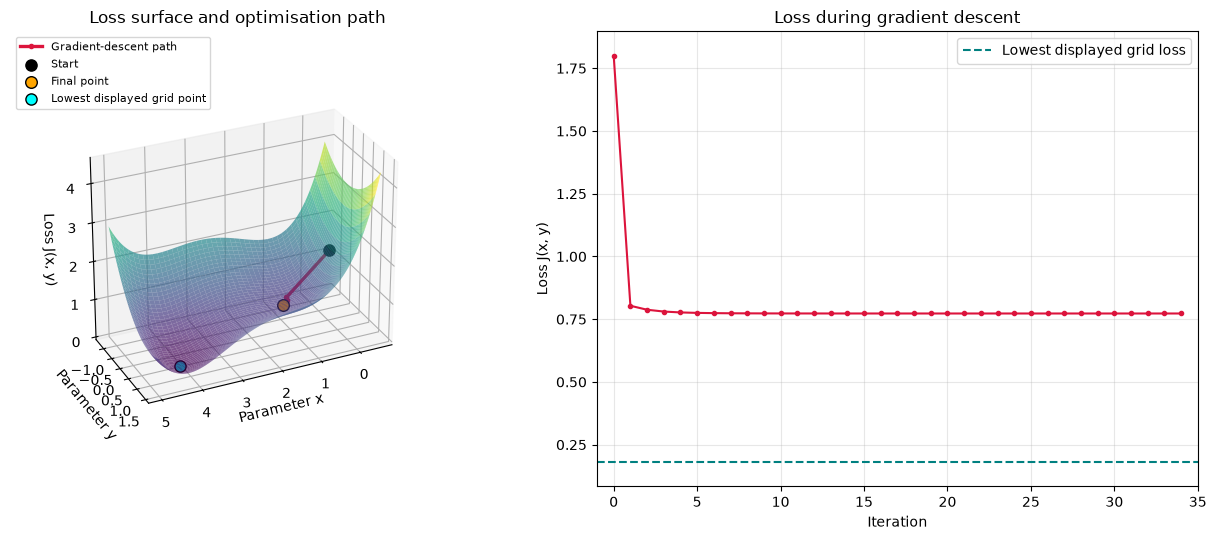

In [6]:
LEARNING_RATE = 0.5
ITERATIONS = 80
START_POINT = [0.0, 0.0]

result = run_simulator(
    loss_function,
    loss_gradient,
    LEARNING_RATE,
    ITERATIONS,
    START_POINT,
)


In [ ]:
plot_interactive_3d(loss_function, result)
